# TP 2 — Classification de chiffres : solution commentée

Solution complète du [TP 2](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

digits = load_digits()
X, y = digits.data, digits.target

## Exercice 1 — Aperçu visuel

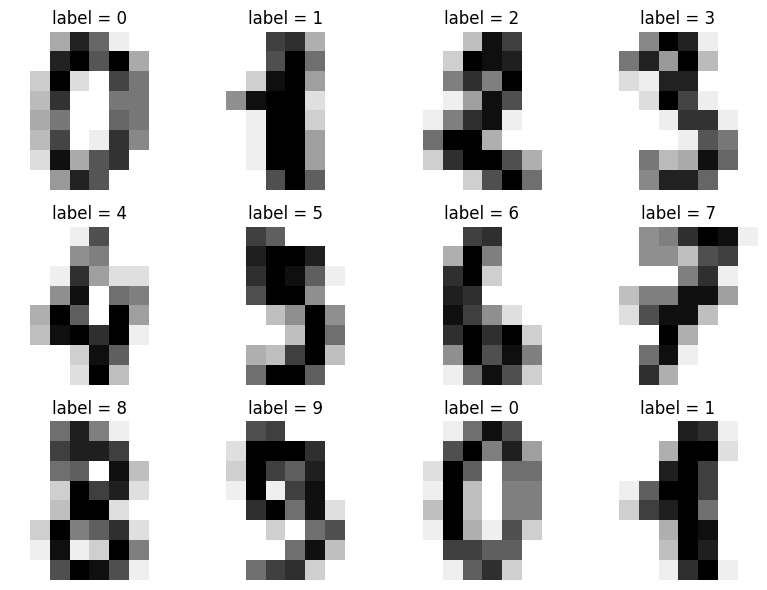

In [2]:
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {digits.target[i]}")
    ax.axis("off")
plt.tight_layout()

## Exercice 2 — Split + Pipeline

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000)),
    ]
)
pipe.fit(X_train, y_train)
print(f"test acc = {pipe.score(X_test, y_test):.3f}")
print(classification_report(y_test, pipe.predict(X_test)))

test acc = 0.967
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.83      0.97      0.90        36
           2       1.00      0.97      0.99        35
           3       1.00      1.00      1.00        37
           4       1.00      0.94      0.97        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.86      0.90        35
           9       0.97      0.97      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



## Exercice 3 — Comparaison de 4 classifieurs

logreg   acc = 0.967
svm      acc = 0.986
tree     acc = 0.847


rf       acc = 0.978


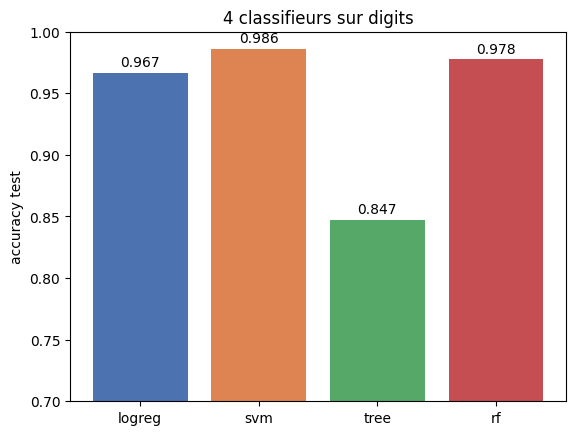

In [4]:
models = {
    "logreg": Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
    "svm": Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf", C=10, gamma="scale"))]),
    "tree": DecisionTreeClassifier(max_depth=10, random_state=0),
    "rf": RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
}

scores = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    scores[name] = m.score(X_test, y_test)
    print(f"{name:7s}  acc = {scores[name]:.3f}")

plt.bar(scores.keys(), scores.values(), color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
plt.ylim(0.7, 1.0)
plt.ylabel("accuracy test")
plt.title("4 classifieurs sur digits")
for k, v in scores.items():
    plt.text(k, v + 0.005, f"{v:.3f}", ha="center")

## Exercice 4 — Matrice de confusion

Meilleur : svm


Text(0.5, 1.0, 'Matrice de confusion — svm')

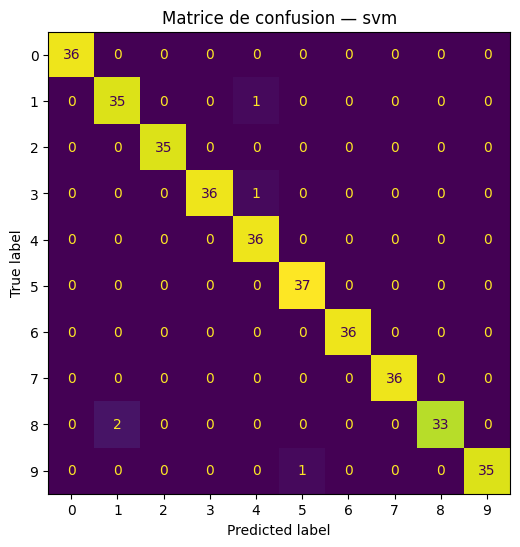

In [5]:
best_name = max(scores, key=scores.get)
best = models[best_name]
print("Meilleur :", best_name)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, ax=ax, colorbar=False)
ax.set_title(f"Matrice de confusion — {best_name}")

5 erreurs sur 360 exemples


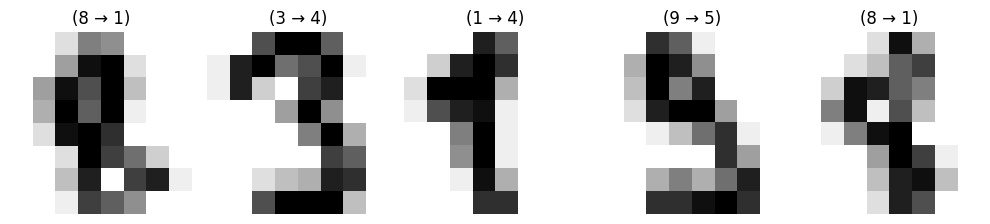

In [6]:
y_pred = best.predict(X_test)
wrong = np.where(y_pred != y_test)[0]
print(f"{len(wrong)} erreurs sur {len(y_test)} exemples")

n_show = min(6, len(wrong))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
for ax, idx in zip(np.atleast_1d(axes), wrong[:n_show]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"({y_test[idx]} → {y_pred[idx]})")
    ax.axis("off")
plt.tight_layout()